# Flux example

This notebook compares the output of Eradiate's Mitsuba and DISORT backends for flux computation.

In [1]:
import eradiate
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from eradiate.experiments import AtmosphereExperiment
from eradiate.units import unit_registry as ureg
import matplotlib.patheffects as patheffects

import eradiate_disort as ed

eradiate.set_mode("ckd")
sns.set_theme(style="ticks")

In [2]:
# Constants
ABSORPTION_DB = (
    "monotropa"  # change to 'panellus' (1 nm resolution) or 'mycena' (10 nm)
)

In [3]:
from eradiate_disort.testing import TestMode

# Overwrite ABSORPTION_DB according to detected test mode
if TestMode.get() == "test":
    ABSORPTION_DB = "mycena"  # fast mode in regression tests
else:
    ABSORPTION_DB = "monotropa"

## Surface spectrum loading

In [4]:
# Load surface spectrum
from eradiate.scenes.spectra import InterpolatedSpectrum

albedo_data = np.loadtxt(
    eradiate.fresolver.resolve("spectra/HAMSTER_spectral_albedo_Gobabeb_015.txt"),
    skiprows=1,
)
albedo_spectrum = InterpolatedSpectrum(
    wavelengths=albedo_data[:, 0], values=albedo_data[:, 1]
)

## Experiment definition

In [5]:
def make_exp(backend, wmin=590.0, wmax=610.0, tau_ref=0.0, spp=10_000):
    toa = 120.0  # km
    boa = 0.0  # km
    spp_flux = max(spp // (32 * 32 * 16), 1)
    srf = {"type": "uniform", "wmin": wmin, "wmax": wmax}
    measures = (
        [
            {
                "id": "toa_flux",
                "type": "distantflux",
                "target": [1e-3, 1e-3, toa] * ureg.km,
                "ray_offset": 1.0 * ureg.m,
                "film_resolution": (32, 32),
                "srf": srf,
                "spp": spp_flux,
            },
            {
                "id": "boa_flux",
                "type": "distantflux",
                "target": [1e-3, 1e-3, boa] * ureg.km,
                "ray_offset": 1.0 * ureg.m,
                "film_resolution": (32, 32),
                "srf": srf,
                "spp": spp_flux,
            },
        ]
        if backend == "mitsuba"
        else {"type": "disort", "srf": srf}
    )

    exp = AtmosphereExperiment(
        geometry={
            "type": "plane_parallel",
            "toa_altitude": 120.0 * ureg.km,
            "zgrid": np.arange(0, 121, 1) * ureg.km,
        },
        surface={"type": "lambertian", "reflectance": 0.5},
        atmosphere={
            "type": "heterogeneous",
            "molecular_atmosphere": {"absorption_data": ABSORPTION_DB},
            # "particle_layers": particle_layer,
        },
        illumination={
            "type": "directional",
            "zenith": 30.0,
            "azimuth": 0.0,
        },
        measures=measures,
    )
    exp.integrator.moment = True

    return exp

## Processing

In [6]:
# exp_kwargs = {"wmin": 600.0, "wmax": 610.0, "tau_ref": 0.0}
exp_kwargs = {"wmin": 600.0, "wmax": 850.0, "tau_ref": 0.0}
# exp_kwargs = {"wmin": 600.0, "wmax": 850.0, "tau_ref": 10.0}
# exp_kwargs = {"wmin": 600.0, "wmax": 610.0, "tau_ref": 10.0}

exp_mitsuba = make_exp("mitsuba", **exp_kwargs)
eradiate.run(exp_mitsuba)
result_mitsuba = exp_mitsuba.results

exp_disort = make_exp("disort", **exp_kwargs)
backend = ed.DisortBackend()
result_disort = backend.run(exp_disort)

0/800|          | 00:00, ETA=?

0/800|          | 00:00, ETA=?

## Flux plotting

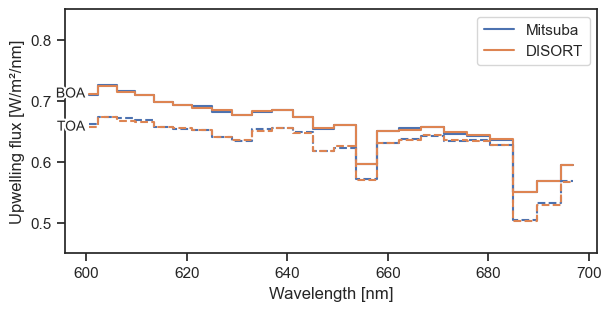

In [7]:
wmin, wmax = 550, 700
c_mitsuba = "C0"
c_disort = "C1"

fig, ax = plt.subplots(1, 1, figsize=(6, 3), layout="constrained", squeeze=True)

for i_loc, (title, mitsuba_measurement_id, disort_zindex, ls) in enumerate(
    [
        ("BOA", "boa_flux", -1, "-"),
        ("TOA", "toa_flux", 0, "--"),
    ]
):
    flux_mitsuba = result_mitsuba[mitsuba_measurement_id]["radiosity"].squeeze()
    flux_disort = result_disort["measure"]["flup"].isel(z=disort_zindex).squeeze()

    x = flux_mitsuba["w"].values
    y = flux_mitsuba.values
    mask = (x >= wmin) & (x <= wmax)
    ax.step(
        x[mask],
        y[mask],
        where="mid",
        label="Mitsuba" if i_loc == 0 else None,
        c=c_mitsuba,
        ls=ls,
    )

    x = flux_disort["w"].values
    y = flux_disort.values
    mask = (x >= wmin) & (x <= wmax)
    ax.step(
        x[mask],
        y[mask],
        where="mid",
        label="DISORT" if i_loc == 0 else None,
        c=c_disort,
        ls=ls,
    )

    ax.annotate(
        title,
        xy=(x[0], y[0]),
        fontsize="small",
        horizontalalignment="right",
        verticalalignment="center",
        xytext=(-3, 0),
        textcoords="offset points",
        path_effects=[patheffects.withStroke(linewidth=3, foreground="white")],
    )

    ax.set_xlabel("Wavelength [nm]")
    ax.set_ylabel("Upwelling flux [W/m²/nm]")
    ax.set_ylim(0.45, 0.85)
    ax.legend()

plt.show()
plt.close()